## Installing necessary libraries

In [3]:
!pip install watermark

In [4]:
!pip install torchinfo

In [5]:
import os
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torchinfo import summary
import torch.quantization
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from tqdm import tqdm

In [6]:
import warnings
warnings.filterwarnings("ignore")

In [7]:
# Print versions using watermark
%reload_ext watermark
%watermark -v -m -p numpy,pandas,matplotlib,seaborn,torch,sklearn,transformers

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.34.0

numpy       : 1.26.4
pandas      : 2.2.3
matplotlib  : 3.7.5
seaborn     : 0.12.2
torch       : 2.5.1+cu121
sklearn     : 1.2.2
transformers: 4.47.0

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.6.56+
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit



In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Dataset Preparation

In [9]:
!wget -O train.tsv "https://raw.githubusercontent.com/clairett/pytorch-sentiment-classification/master/data/SST2/train.tsv"
!wget -O test.tsv "https://raw.githubusercontent.com/clairett/pytorch-sentiment-classification/master/data/SST2/test.tsv"

--2025-04-15 18:54:49--  https://raw.githubusercontent.com/clairett/pytorch-sentiment-classification/master/data/SST2/train.tsv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 720259 (703K) [text/plain]
Saving to: ‘train.tsv’

train.tsv           100%[===================>] 703.38K  --.-KB/s    in 0.04s   

2025-04-15 18:54:49 (15.7 MB/s) - ‘train.tsv’ saved [720259/720259]

--2025-04-15 18:54:49--  https://raw.githubusercontent.com/clairett/pytorch-sentiment-classification/master/data/SST2/test.tsv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response...

In [10]:
# Load the dataset
train_df = pd.read_csv("train.tsv", delimiter="\t", header=None, names=["Review","Sentiment"])
test_df = pd.read_csv("test.tsv", delimiter="\t", header=None, names=["Review","Sentiment"])

In [11]:
train_df.sample(5)

,Review,Sentiment
2907,"the movie 's messages are quite admirable , bu...",0
6425,is anyone else out there getting tired of the ...,0
2558,there 's nothing interesting in unfaithful wha...,0
4336,makes the case for a strong education and good...,1
1325,at once disarmingly straightforward and striki...,1


In [12]:
X_train = train_df['Review']
y_train = train_df['Sentiment']
X_test = test_df['Review']
y_test = test_df['Sentiment']

In [13]:
# Split training data into train and validation (80-20 split)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [14]:
print(f"Shape of training data: {X_train.shape}")
print(f"Shape of validation data: {X_val.shape}")
print(f"Shape of testing data: {X_test.shape}")

Shape of training data: (5536,)
Shape of validation data: (1384,)
Shape of testing data: (1821,)


## Construct a Multi-Layer Perceptron (MLP) model.

In [15]:
class MLPModel(nn.Module):
    def __init__(self, input_size=10000, hidden_sizes=[512, 256, 128, 64], output_size=2):
        super(MLPModel, self).__init__()

        # Define layers
        self.fc1 = nn.Linear(input_size, hidden_sizes[0])
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.fc3 = nn.Linear(hidden_sizes[1], hidden_sizes[2])
        self.fc4 = nn.Linear(hidden_sizes[2], hidden_sizes[3])
        self.fc5 = nn.Linear(hidden_sizes[3], output_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)  # Dropout for regularization

    def forward(self, x):
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.dropout(self.relu(self.fc2(x)))
        x = self.dropout(self.relu(self.fc3(x)))
        x = self.dropout(self.relu(self.fc4(x)))
        x = self.fc5(x)
        return x


In [16]:
# Initialize Model
model = MLPModel()

# Print Summary (batch_size=1, input_size=10000)
summary(model, input_size=(1, 10000), col_names=["input_size", "output_size", "num_params", "trainable"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
MLPModel                                 [1, 10000]                [1, 2]                    --                        True
├─Linear: 1-1                            [1, 10000]                [1, 512]                  5,120,512                 True
├─ReLU: 1-2                              [1, 512]                  [1, 512]                  --                        --
├─Dropout: 1-3                           [1, 512]                  [1, 512]                  --                        --
├─Linear: 1-4                            [1, 512]                  [1, 256]                  131,328                   True
├─ReLU: 1-5                              [1, 256]                  [1, 256]                  --                        --
├─Dropout: 1-6                           [1, 256]                  [1, 256]                  --                        --
├─Linear: 1

## Bag-of-words implementation for creating embeddings

In [17]:
vectorizer = CountVectorizer(max_features=10000)
X_train_bow = vectorizer.fit_transform(X_train).toarray()
X_val_bow = vectorizer.transform(X_val).toarray()
X_test_bow = vectorizer.transform(X_test).toarray()

In [18]:
X_train_bow.shape

(5536, 10000)

In [19]:
# Convert labels to NumPy arrays before converting to PyTorch tensors
y_train = torch.tensor(y_train.to_numpy(), dtype=torch.long)
y_val = torch.tensor(y_val.to_numpy(), dtype=torch.long)
y_test = torch.tensor(y_test.to_numpy(), dtype=torch.long)

## Model training

In [20]:
# Hyperparameters
HYPERPARAMS = {
    "input_size": 10000, 
    "hidden_sizes": [512, 256, 128, 64],  
    "output_size": 2,  
    "epochs": 10,
    "batch_size": 32,
    "learning_rate": 0.0001
}

In [21]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

def train_model(model, X_train, y_train, X_val, y_val, checkpoint_path):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=HYPERPARAMS["learning_rate"])
    criterion = torch.nn.CrossEntropyLoss()

    torch.cuda.empty_cache()  # Free up memory

    train_loader = DataLoader(
        TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long)),
        batch_size=HYPERPARAMS["batch_size"], shuffle=True, pin_memory=True
    )
    val_loader = DataLoader(
        TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long)),
        batch_size=HYPERPARAMS["batch_size"], shuffle=False, pin_memory=True
    )

    best_val_acc = 0.0
    best_model_state = None
    best_optimizer_state = None
    best_loss = None

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_accuracy": []
    }

    for epoch in range(HYPERPARAMS["epochs"]):
        model.train()
        total_train_loss = 0

        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        # Validation
        model.eval()
        total_val_loss = 0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)

                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                total_val_loss += loss.item()

                preds = torch.argmax(outputs, axis=1)
                val_correct += (preds == batch_y).sum().item()
                val_total += batch_y.size(0)

        val_acc = val_correct / val_total
        avg_train_loss = total_train_loss / len(train_loader)
        avg_val_loss = total_val_loss / len(val_loader)

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["val_accuracy"].append(val_acc)

        print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}, Val Accuracy = {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_loss = avg_val_loss
            best_model_state = model.state_dict().copy()
            best_optimizer_state = optimizer.state_dict().copy()

    if best_model_state:
        checkpoint = {
            "model_state_dict": best_model_state,
            "optimizer_state_dict": best_optimizer_state,
            "hyperparameters": HYPERPARAMS,
            "performance": {
                "final_loss": best_loss,
                "final_accuracy": best_val_acc
            }
        }
        torch.save(checkpoint, checkpoint_path)
        print(f"Best model saved with Validation Accuracy: {best_val_acc:.4f}")

    return model, history


In [22]:
# Initialize model
model_bow = MLPModel(input_size=10000)

# Train the model
trained_model_bow, history_bow = train_model(model_bow, X_train_bow, y_train, X_val_bow, y_val, checkpoint_path="checkpoint")

Epoch 1: Train Loss = 0.6914, Val Loss = 0.6883, Val Accuracy = 0.5152
Epoch 2: Train Loss = 0.5802, Val Loss = 0.4649, Val Accuracy = 0.7854
Epoch 3: Train Loss = 0.2734, Val Loss = 0.4809, Val Accuracy = 0.7934
Epoch 4: Train Loss = 0.1221, Val Loss = 0.5870, Val Accuracy = 0.7934
Epoch 5: Train Loss = 0.0580, Val Loss = 0.7277, Val Accuracy = 0.7934
Epoch 6: Train Loss = 0.0283, Val Loss = 0.8877, Val Accuracy = 0.7803
Epoch 7: Train Loss = 0.0179, Val Loss = 0.9298, Val Accuracy = 0.7919
Epoch 8: Train Loss = 0.0090, Val Loss = 1.0355, Val Accuracy = 0.7926
Epoch 9: Train Loss = 0.0063, Val Loss = 1.0566, Val Accuracy = 0.8078
Epoch 10: Train Loss = 0.0061, Val Loss = 1.1453, Val Accuracy = 0.7962
Best model saved with Validation Accuracy: 0.8078


In [23]:
def plot_training_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Loss Curve")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["val_accuracy"], label="Validation Accuracy", color="green")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Validation Accuracy Curve")
    plt.legend()

    plt.tight_layout()
    plt.show()

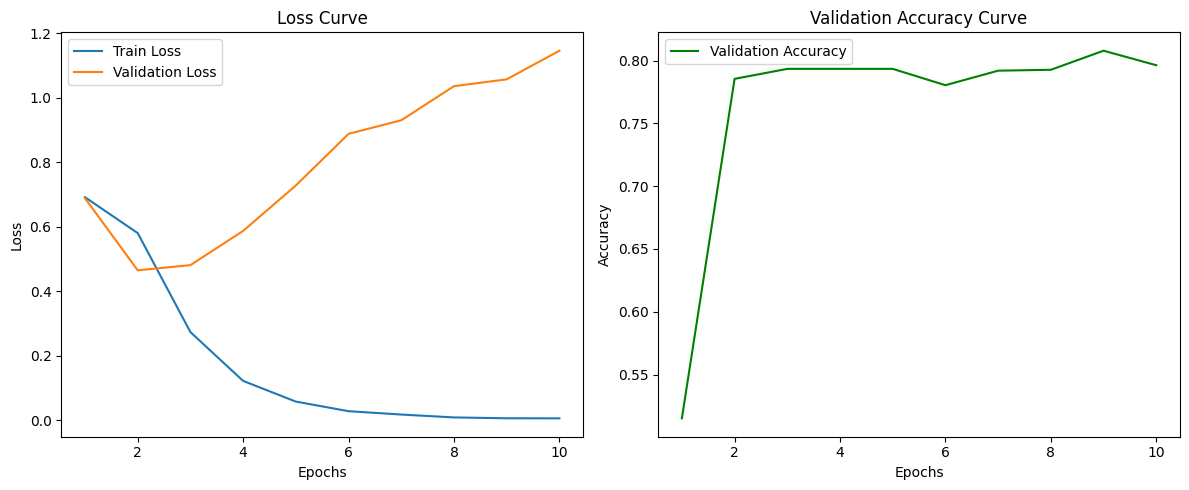

In [24]:
plot_training_history(history_bow)

## Quantization

In [25]:
# Dynamic Quantization typically runs on CPU.
eval_device = torch.device("cpu") 

In [26]:
def get_model_size(model, label=""):
    torch.save(model.state_dict(), "temp_model_state.pt")
    size_mb = os.path.getsize("temp_model_state.pt") / (1024 * 1024)
    os.remove("temp_model_state.pt")
    print(f"Size ({label}): {size_mb:.4f} MB")
    return size_mb

In [27]:
def evaluate_model(model, X_test, y_test, device, input_dtype=torch.float32):
    model.to(device)
    model.eval()

    # Prepare DataLoader for evaluation
    test_loader = DataLoader(
        TensorDataset(torch.tensor(X_test, dtype=torch.float32), # Input always starts as float32
                      torch.tensor(y_test, dtype=torch.long)),
        batch_size=128, 
        shuffle=False
    )

    correct = 0
    total = 0
    total_inference_time = 0
    num_samples = 0

    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            # Move data to the evaluation device and cast to required dtype
            batch_X = batch_X.to(device).to(input_dtype) 
            batch_y = batch_y.to(device)

            start_time = time.perf_counter()
            
            # Perform inference
            outputs = model(batch_X)
            
            end_time = time.perf_counter()
            
            total_inference_time += (end_time - start_time)
            num_samples += batch_X.size(0)

            preds = torch.argmax(outputs, axis=1)
            correct += (preds == batch_y).sum().item()
            total += batch_y.size(0)

    accuracy = 100 * (correct / total)
    # Calculate average inference time per sample in milliseconds
    avg_inference_time_ms = (total_inference_time / num_samples) * 1000 

    print(f"Accuracy: {accuracy:.2f}%")
    print(f"Average Inference Time: {avg_inference_time_ms:.4f} ms/sample")
    
    return accuracy, avg_inference_time_ms

In [29]:
# Load the Original Model
# Create a new instance of the model architecture
original_model = MLPModel(input_size=HYPERPARAMS["input_size"], 
                          hidden_sizes=HYPERPARAMS["hidden_sizes"], 
                          output_size=HYPERPARAMS["output_size"])

# Load the saved state dict from the checkpoint
checkpoint = torch.load("/kaggle/working/checkpoint", map_location=eval_device) # Load directly to eval device
original_model.load_state_dict(checkpoint['model_state_dict'])
original_model.to(eval_device)
original_model.eval() # Set to evaluation mode

print("Original model loaded successfully.")

Original model loaded successfully.


## Dynamic Quantization

In [ ]:
# Dynamic quantization modifies the model in place, so working on a copy.
model_to_quantize = copy.deepcopy(original_model).to("cpu")
model_to_quantize.eval()

# Apply dynamic quantization
model_dynamic_quantized = torch.quantization.quantize_dynamic(
    model=model_to_quantize,
    qconfig_spec={nn.Linear},  # Quantize Linear layers to qint8
    dtype=torch.qint8          
)

print("Dynamic quantization applied.")
print(model_dynamic_quantized) 

Dynamic quantization applied.
MLPModel(
  (fc1): DynamicQuantizedLinear(in_features=10000, out_features=512, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
  (fc2): DynamicQuantizedLinear(in_features=512, out_features=256, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
  (fc3): DynamicQuantizedLinear(in_features=256, out_features=128, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
  (fc4): DynamicQuantizedLinear(in_features=128, out_features=64, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
  (fc5): DynamicQuantizedLinear(in_features=64, out_features=2, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
)


## Half Precision

In [31]:
# Create a copy and convert to half precision
model_half = copy.deepcopy(original_model).to(eval_device) 
model_half.eval() 
model_half = model_half.half() # Convert model parameters and buffers to FP16

print("Half precision conversion applied.")

Half precision conversion applied.


## Evaluating Models and Collecting Results

In [32]:
results = []

# 1. Evaluate Original Model
original_model_size = get_model_size(original_model, "Original")
original_accuracy, original_inference_time = evaluate_model(
    original_model, X_test_bow, y_test, eval_device, input_dtype=torch.float32
)
results.append(["Original", original_accuracy, original_model_size, original_inference_time])

Size (Original): 20.1953 MB
Accuracy: 79.24%
Average Inference Time: 0.0879 ms/sample


In [33]:
# 2. Evaluate Dynamic Quantized Model
dynamic_model_size = get_model_size(model_dynamic_quantized, "Dynamic Quantized")
dynamic_accuracy, dynamic_inference_time = evaluate_model(
    model_dynamic_quantized, X_test_bow, y_test, torch.device("cpu"), input_dtype=torch.float32
    # Input still float32, model handles internal conversion
)
results.append(["Dynamic", dynamic_accuracy, dynamic_model_size, dynamic_inference_time])

Size (Dynamic Quantized): 5.0574 MB
Accuracy: 79.35%
Average Inference Time: 0.0621 ms/sample


In [34]:
# 3. Evaluate Half Precision Model
half_model_size = get_model_size(model_half, "Half Precision")
half_accuracy, half_inference_time = evaluate_model(
    model_half, X_test_bow, y_test, eval_device, input_dtype=torch.float16 # Input must be FP16
)
results.append(["Half", half_accuracy, half_model_size, half_inference_time])

Size (Half Precision): 10.0995 MB
Accuracy: 79.24%
Average Inference Time: 6.9205 ms/sample


## Final Table

In [36]:
results_df = pd.DataFrame(results, columns=["Model Name", "Accuracy (Out of 100)", "Storage (In MB)", "Inference time (In ms)"])
results_df = results_df.round(4) # Round for display

print("\nFinal Table:")
print(f"{'S.I.':<5} {'Model Name':<10} {'Accuracy (Out of 100)':<25} {'Storage (In MB)':<20} {'Inference time (In ms)':<25}")
print("-" * 85)
for i, row in results_df.iterrows():
    print(f"{i+1:<5} {row['Model Name']:<10} {row['Accuracy (Out of 100)']:<25.4f} {row['Storage (In MB)']:<20.4f} {row['Inference time (In ms)']:<25.4f}")


Final Table:
S.I.  Model Name Accuracy (Out of 100)     Storage (In MB)      Inference time (In ms)   
-------------------------------------------------------------------------------------
1     Original   79.2422                   20.1953              0.0879                   
2     Dynamic    79.3520                   5.0574               0.0621                   
3     Half       79.2422                   10.0995              6.9205                   
